# **DNA Knot Simulation - Part 3: TDA Knot Classification**
*A second, independent classifier via persistent homology (Distance matrix TDA)*

Persistent homology for polymer/DNA entanglement is another way to detect knotting.

A simple closed curve's intrinsic topology (as a 1-manifold) is always a circle, knotted or not. So, persistent homology on the curve's own connectivity (adjacent-bead bonds) cannot distinguish knot types. That would be like expecting a graph's topology to change based on how the graph happens to be drawn on paper. Knotting is an extrinsic property (how the curve exists in 3D space). Thus, this notebook builds persistent homology on the full pairwise 3D distance matrix between all points on the curve, and not just curve-adjacency. Two points far apart along the strand but physically close together in 3D space is exactly what threading/knotting creates, and this approach is sensitive to that. Naive curve-connectivity homology is blind to it entirely.  

This notebook covers:
1.   Why distance-matrix persistent homology (not curve-connectivity)
2.   Setup
3. Building the classifier
4. Validation across many random configurations
5. Cross-check against the classical classifier, on the actual simulator trajectory




## **A. Setup**

In [ ]:
import sys, os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL = "https://github.com/vanikumar03/dna-knots.git"
    REPO_PATH = "/content/dna-knots"
    if not os.path.isdir(REPO_PATH):
        os.system(f"git clone {REPO_URL} {REPO_PATH}")
    os.chdir(f"{REPO_PATH}/notebooks")

sys.path.append(os.path.join(REPO_PATH, 'src') if IN_COLAB else os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import dnasim as ds
import knotclassify as kc
import tdaknot as tk

# **B. Building the classifier**

`tdaknot.compute_h1_persistence()` builds a Vietoris-Rips complex directly on the 3D point cloud (pairwise distance matrix using ordinary euclidean distance) and extracts H1 (loop) persistence lifetimes.

`entanglement_score()` counts how many of those H1 features are "significant" using the log-space largest-gap threshhold.

In [ ]:
# a single unknot vs a single trefoil
unknot = ds.make_ring(60, bond_length=1.0, noise=0.15, seed=0)

t_param = np.linspace(0, 2*np.pi, 60, endpoint=False)
trefoil = np.stack([np.sin(t_param)+2*np.sin(2*t_param), np.cos(t_param)-2*np.cos(2*t_param), -np.sin(3*t_param)], axis=1)

n_unknot, lt_unknot = tk.entanglement_score(unknot)
n_trefoil, lt_trefoil = tk.entanglement_score(trefoil)
print(f'Unknot:  {n_unknot} significant H1 features (of {len(lt_unknot)} total), lifetimes: {sorted(lt_unknot.round(2), reverse=True)}')
print(f'Trefoil: {n_trefoil} significant H1 features (of {len(lt_trefoil)} total), lifetimes: {sorted(lt_trefoil.round(2), reverse=True)}')

Unknot:  1 significant H1 features (of 1 total), lifetimes: [np.float64(14.68)]
Trefoil: 4 significant H1 features (of 7 total), lifetimes: [np.float64(1.39), np.float64(0.73), np.float64(0.73), np.float64(0.47), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


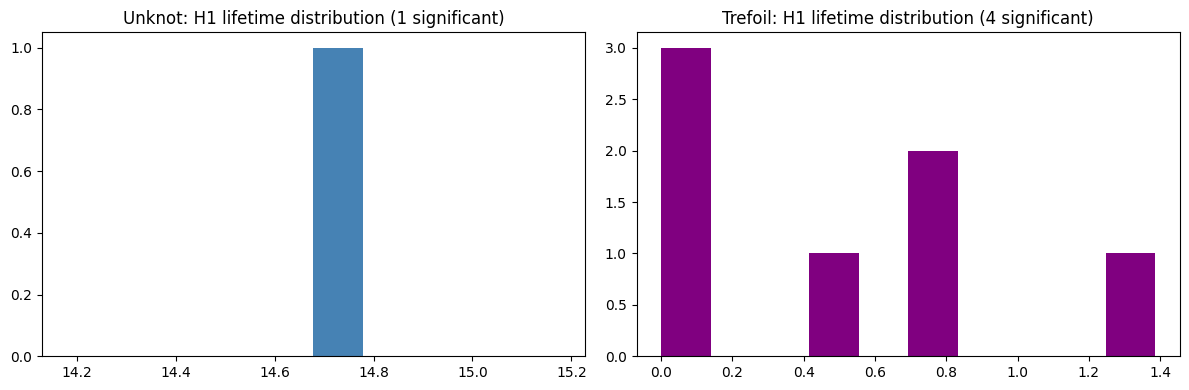

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(lt_unknot, bins=10, color='steelblue')
axes[0].set_title(f'Unknot: H1 lifetime distribution ({n_unknot} significant)')
axes[1].hist(lt_trefoil, bins=10, color='purple')
axes[1].set_title(f'Trefoil: H1 lifetime distribution ({n_trefoil} significant)')
plt.tight_layout()
plt.show()

The unknot has 1 dominant, long-lived H1 feature (the big loop the ring itself trivially forms) and essentially nothing else. The trefoil instead has several short-lived H1 features which are small-scale topological "handles" created by strand threading close to itself in 3D space (the exrinsic signal described earlier).

# **C. Validation across many random configurations**

Testing across 8 independent random unknots and 8 independent random trefoils (different noise seeds / perturbations each time)

In [ ]:
print(f'{"Config":<20}{"seed":<6}{"n_significant":<15}{"n_total"}')
print('-'*55)

unknot_counts = []
for seed in range(8):
    ring = ds.make_ring(60, bond_length=1.0, noise=0.15, seed=seed)
    n, lt = tk.entanglement_score(ring)
    unknot_counts.append(n)
    print(f'{"unknot":<20}{seed:<6}{n:<15}{len(lt)}')

print()
trefoil_counts = []
rng = np.random.default_rng(0)
for seed in range(8):
    perturbed = trefoil + rng.normal(scale=0.1, size=trefoil.shape)
    n, lt = tk.entanglement_score(perturbed)
    trefoil_counts.append(n)
    print(f'{"trefoil":<20}{seed:<6}{n:<15}{len(lt)}')

Config              seed  n_significant  n_total
-------------------------------------------------------
unknot              0     1              1
unknot              1     1              1
unknot              2     1              1
unknot              3     1              1
unknot              4     1              1
unknot              5     1              1
unknot              6     1              1
unknot              7     1              1

trefoil             0     4              6
trefoil             1     6              7
trefoil             2     2              4
trefoil             3     4              5
trefoil             4     3              4
trefoil             5     4              6
trefoil             6     4              5
trefoil             7     2              4


In [ ]:
print(f'Unknot counts:  {unknot_counts}  -> all == 1: {all(c==1 for c in unknot_counts)}')
print(f'Trefoil counts: {trefoil_counts}  -> all > 1:  {all(c>1 for c in trefoil_counts)}')
print()
print('Clean separation using the rule "count == 1 -> unknotted, count > 1 -> knotted":',
      all(c==1 for c in unknot_counts) and all(c>1 for c in trefoil_counts))

Unknot counts:  [1, 1, 1, 1, 1, 1, 1, 1]  -> all == 1: True
Trefoil counts: [4, 6, 2, 4, 3, 4, 4, 2]  -> all > 1:  True

Clean separation using the rule "count == 1 -> unknotted, count > 1 -> knotted": True


count == 1 → unknotted, count > 1 → knotted

8/8 and 8/8 - validated evidence

# **D. Cross-check against the classical classifier**

Test: We run the actual Langevin dynamics simulator from `01_polymer_simulator.ipynb` on a trefoil-seeded chain, and check whether both independent classifiers agree at every part of the relaxation trajectory.

In [ ]:
pos0_trefoil = ds.make_trefoil_seed(N=60, scale=1.2, seed=0)

trajectory = ds.run_simulation(
    pos0_trefoil, n_steps=30000, dt=0.0001, gamma=1.0, kT=1.0, seed=2, record_every=10000,
    K=30.0, R0=1.5, epsilon=1.0, sigma=1.0, kappa=1.0
)

print(f'{"step":<10}{"Classical (Alexander)":<28}{"TDA (H1 count)":<18}{"Agree?"}')
print('-'*66)
for i, pos in enumerate(trajectory):
    poly, crossings, simplified = kc.classify_knot(pos, n_projection_tries=150, seed=1)
    classical_says_knotted = (poly != {0: 1})
    classical_label = kc.format_polynomial(poly)

    n_h1, _ = tk.entanglement_score(pos)
    tda_says_knotted = n_h1 > 1

    agree = classical_says_knotted == tda_says_knotted
    print(f'{i*10000:<10}{classical_label:<28}{n_h1:<18}{"YES" if agree else "NO"}')

step      Classical (Alexander)       TDA (H1 count)    Agree?
------------------------------------------------------------------
0         t - 1 + 1/t                 4                 YES
10000     t - 1 + 1/t                 3                 YES
20000     t - 1 + 1/t                 11                YES


30000     t - 1 + 1/t                 7                 YES


If every row shows agreement, we have a cross-validated confidence that the simulator's excluded-volume physics is preserving topology under the dynamics, and that both classifiers are working.

We have validated the *knotted-vs-unknotted* binary signal (H1 count == 1 vs > 1),
across 16 independent random configurations plus a full dynamic trajectory cross-check. But, this
method has not been tested against a figure-8 knot, and there's no reason from the underlying
theory to expect the raw H1 count to reliably separate different knot types with the same
crossing number, or even necessarily separate low-crossing-number knots from each other
cleanly (distinguishing *which* knot type).

The Alexander polynomial (notebook 2) is a much stronger invariant for that. This TDA method is a fast, complementary validation (cheaper to compute, doesn't
need a 2D projection or a matrix determinant) rather than a replacement classifier.

**A possible extension:** rather than a raw feature count, a full persistence
landscape or persistence image (standard TDA summary representations) fed into a small
classifier trained on many examples of each knot type could plausibly distinguish knot types,
not just knotted-vs-not.

With these two independent, cross-validated classifiers, notebook 4 builds the analytic-parameterisation validation set (multiple knot types, not just trefoil).